# 2026 COMP90042 Project
*Make sure you change the file name with your group id.*

# Readme
*If there is something to be noted for the marker, please mention here.*

*If you are planning to implement a program with Object Oriented Programming style, please put those the bottom of this ipynb file*

# 1.DataSet Processing
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [1]:
!pip install nltk contractions rank_bm25 --quiet

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

print("Done.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.1 MB/s eta 0:00:00
Done.


In [4]:
import json

TRAIN_PATH    = '/content/train-claims.json'
DEV_PATH      = '/content/dev-claims.json'
TEST_PATH     = '/content/test-claims-unlabelled.json'
EVIDENCE_PATH = '/content/evidence.json'

OUTPUT_DIR    = '/content/preprocessed'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Confirm files exist
for name, path in [
    ('train-claims',         TRAIN_PATH),
    ('dev-claims',           DEV_PATH),
    ('test-claims',          TEST_PATH),
    ('evidence',             EVIDENCE_PATH),
]:
    status = '✓' if os.path.exists(path) else '✗ MISSING'
    print(f'  {status}  {name}')

# Load all files
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

print('\nLoading train-claims...')
train_claims = load_json(TRAIN_PATH)

print('Loading dev-claims...')
dev_claims = load_json(DEV_PATH)

print('Loading test-claims...')
test_claims = load_json(TEST_PATH)

print('Loading evidence (may take ~60s)...')
evidence = load_json(EVIDENCE_PATH)

print('\nAll loaded.')
print(f'  Train claims : {len(train_claims):,}')
print(f'  Dev claims   : {len(dev_claims):,}')
print(f'  Test claims  : {len(test_claims):,}')
print(f'  Evidence     : {len(evidence):,}')

  ✓  train-claims
  ✓  dev-claims
  ✓  test-claims
  ✓  evidence

Loading train-claims...
Loading dev-claims...
Loading test-claims...
Loading evidence (may take ~60s)...

All loaded.
  Train claims : 1,228
  Dev claims   : 154
  Test claims  : 153
  Evidence     : 1,208,827


In [5]:
# Check A — print one sample from each
print('=== Sample train claim ===')
sample_key = list(train_claims.keys())[0]
print(json.dumps(train_claims[sample_key], indent=2))

print('\n=== Sample evidence passage ===')
ev_key = list(evidence.keys())[0]
print(f'{ev_key}: {evidence[ev_key]}')

# Check B — required fields
REQUIRED = {'claim_text', 'claim_label', 'evidences'}
errors = []
for cid, entry in train_claims.items():
    missing = REQUIRED - set(entry.keys())
    if missing:
        errors.append(f'{cid} missing: {missing}')
if errors:
    print(f'\n✗ {len(errors)} claims missing fields')
    for e in errors[:5]:
        print(f'  {e}')
else:
    print('\n✓ All train claims have required fields')

# Check C — evidence IDs valid
evidence_ids = set(evidence.keys())
missing_ids = 0
for cid, entry in train_claims.items():
    for eid in entry.get('evidences', []):
        if eid not in evidence_ids:
            missing_ids += 1
if missing_ids:
    print(f'✗ {missing_ids} evidence IDs not found in evidence.json')
else:
    print('✓ All evidence IDs valid')

=== Sample train claim ===
{
  "claim_text": "Not only is there no scientific evidence that CO2 is a pollutant, higher CO2 concentrations actually help ecosystems support more plant and animal life.",
  "claim_label": "DISPUTED",
  "evidences": [
    "evidence-442946",
    "evidence-1194317",
    "evidence-12171"
  ]
}

=== Sample evidence passage ===
evidence-0: John Bennet Lawes, English entrepreneur and agricultural scientist

✓ All train claims have required fields
✓ All evidence IDs valid



Train class distribution (total=1228):
  SUPPORTS            :   519  (42.3%)
  REFUTES             :   199  (16.2%)
  NOT_ENOUGH_INFO     :   386  (31.4%)
  DISPUTED            :   124  (10.1%)

Dev class distribution (total=154):
  SUPPORTS            :    68  (44.2%)
  REFUTES             :    27  (17.5%)
  NOT_ENOUGH_INFO     :    41  (26.6%)
  DISPUTED            :    18  (11.7%)


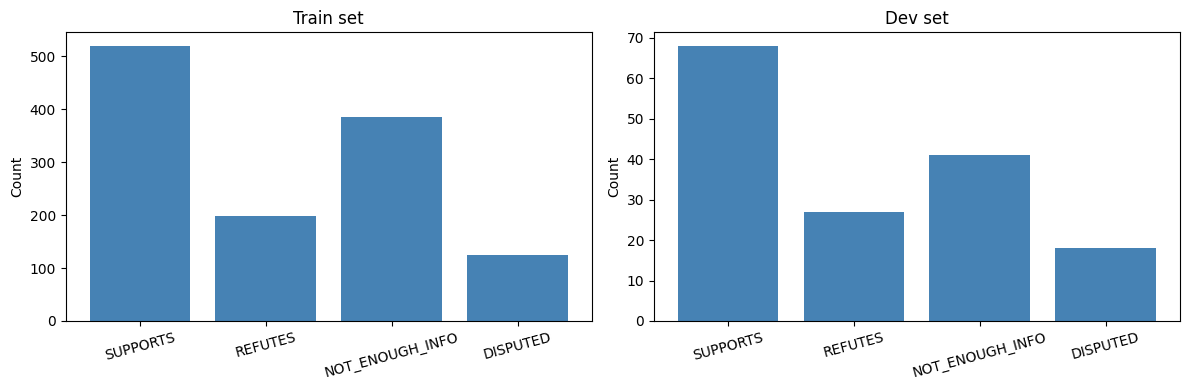


Claim length (words):
  Min    : 4
  Max    : 67
  Mean   : 20.1
  Median : 19.0

Evidence passage length distribution:
  ≤5 words       :   13,578
  6–10 words     :  180,771
  11–20 words    :  547,481
  21–50 words    :  451,498
  51–100 words   :   15,217
  100+ words     :      282

Gold evidences per claim:
  Min    : 1
  Max    : 5
  Mean   : 3.4


In [6]:
import collections
import numpy as np
import matplotlib.pyplot as plt

# ── Class distribution ──
LABELS = ['SUPPORTS', 'REFUTES', 'NOT_ENOUGH_INFO', 'DISPUTED']

def class_distribution(dataset, name):
    counts = collections.Counter(
        v['claim_label'] for v in dataset.values()
    )
    total = sum(counts.values())
    print(f'\n{name} class distribution (total={total}):')
    for label in LABELS:
        n = counts.get(label, 0)
        print(f'  {label:<20}: {n:>5}  ({100*n/total:.1f}%)')
    return counts

train_counts = class_distribution(train_claims, 'Train')
dev_counts   = class_distribution(dev_claims,   'Dev')

# ── Plot class distribution ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (counts, title) in zip(axes, [
    (train_counts, 'Train set'),
    (dev_counts,   'Dev set'),
]):
    vals = [counts.get(l, 0) for l in LABELS]
    ax.bar(LABELS, vals, color='steelblue')
    ax.set_title(title)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'class_distribution.png'), dpi=150)
plt.show()

# ── Claim length distribution ──
claim_lengths = [
    len(v['claim_text'].split())
    for v in train_claims.values()
]
print(f'\nClaim length (words):')
print(f'  Min    : {np.min(claim_lengths)}')
print(f'  Max    : {np.max(claim_lengths)}')
print(f'  Mean   : {np.mean(claim_lengths):.1f}')
print(f'  Median : {np.median(claim_lengths):.1f}')

# ── Evidence length distribution ──
ev_lengths = [len(text.split()) for text in evidence.values()]
buckets = {
    '≤5 words'    : sum(1 for l in ev_lengths if l <= 5),
    '6–10 words'  : sum(1 for l in ev_lengths if 6 <= l <= 10),
    '11–20 words' : sum(1 for l in ev_lengths if 11 <= l <= 20),
    '21–50 words' : sum(1 for l in ev_lengths if 21 <= l <= 50),
    '51–100 words': sum(1 for l in ev_lengths if 51 <= l <= 100),
    '100+ words'  : sum(1 for l in ev_lengths if l > 100),
}
print('\nEvidence passage length distribution:')
for bucket, count in buckets.items():
    print(f'  {bucket:<15}: {count:>8,}')

# ── Evidences per claim ──
ev_per_claim = [
    len(v['evidences']) for v in train_claims.values()
]
print(f'\nGold evidences per claim:')
print(f'  Min    : {np.min(ev_per_claim)}')
print(f'  Max    : {np.max(ev_per_claim)}')
print(f'  Mean   : {np.mean(ev_per_claim):.1f}')

In [10]:
import re
import contractions
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

STOPWORDS = set(stopwords.words('english'))

def clean_text(text):
    # Guard against empty or non-string input
    if not isinstance(text, str) or len(text.strip()) == 0:
        return []

    # 1. Expand contractions — wrapped in try/except
    #    because the contractions library crashes on some
    #    very short or unusual strings in the evidence corpus
    try:
        text = contractions.fix(text)
    except Exception:
        pass  # if it fails, just keep the original text

    # 2. Lowercase
    text = text.lower()

    # 3. Remove punctuation and special characters
    text = re.sub(r'[^a-z0-9\s]', ' ', text)

    # 4. Tokenise
    tokens = word_tokenize(text)

    # 5. Remove stopwords
    tokens = [t for t in tokens if t not in STOPWORDS]

    # 6. Remove empty or single-character tokens
    tokens = [t for t in tokens if len(t) > 1]

    return tokens

# Test it
test_sentence = "The Earth's climate isn't changing rapidly, according to some scientists."
print('Raw    :', test_sentence)
print('Cleaned:', clean_text(test_sentence))

# Test edge cases that previously caused the crash
print('Empty  :', clean_text(''))
print('Number :', clean_text('42'))
print('Short  :', clean_text('a'))

Raw    : The Earth's climate isn't changing rapidly, according to some scientists.
Cleaned: ['earth', 'climate', 'changing', 'rapidly', 'according', 'scientists']
Empty  : []
Number : ['42']
Short  : []


In [11]:
def clean_claims(dataset):
    cleaned = {}
    for cid, entry in dataset.items():
        cleaned[cid] = {
            **entry,
            'clean_tokens': clean_text(entry['claim_text'])
        }
    return cleaned

print('Cleaning train claims...')
train_clean = clean_claims(train_claims)

print('Cleaning dev claims...')
dev_clean = clean_claims(dev_claims)

print('Cleaning test claims...')
test_clean = clean_claims(test_claims)

# Verify
sample = list(train_clean.values())[0]
print('\nSample:')
print('  Raw    :', sample['claim_text'])
print('  Tokens :', sample['clean_tokens'])

Cleaning train claims...
Cleaning dev claims...
Cleaning test claims...

Sample:
  Raw    : Not only is there no scientific evidence that CO2 is a pollutant, higher CO2 concentrations actually help ecosystems support more plant and animal life.
  Tokens : ['scientific', 'evidence', 'co2', 'pollutant', 'higher', 'co2', 'concentrations', 'actually', 'help', 'ecosystems', 'support', 'plant', 'animal', 'life']


In [12]:
evidence_clean = {}

total = len(evidence)
for i, (eid, text) in enumerate(evidence.items()):
    evidence_clean[eid] = clean_text(text)
    if (i + 1) % 200000 == 0:
        print(f'  Processed {i+1:,} / {total:,}')

print(f'Done. Total cleaned: {len(evidence_clean):,}')

# Verify
sample_eid = list(evidence.keys())[0]
print('\nSample:')
print('  Raw    :', evidence[sample_eid])
print('  Tokens :', evidence_clean[sample_eid])

  Processed 200,000 / 1,208,827
  Processed 400,000 / 1,208,827
  Processed 600,000 / 1,208,827
  Processed 800,000 / 1,208,827
  Processed 1,000,000 / 1,208,827
  Processed 1,200,000 / 1,208,827
Done. Total cleaned: 1,208,827

Sample:
  Raw    : John Bennet Lawes, English entrepreneur and agricultural scientist
  Tokens : ['john', 'bennet', 'lawes', 'english', 'entrepreneur', 'agricultural', 'scientist']


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

LABEL2ID = {
    'SUPPORTS': 0, 'REFUTES': 1,
    'NOT_ENOUGH_INFO': 2, 'DISPUTED': 3
}

def build_input(claim_entry):
    # Combine claim text + all gold evidence texts into one string
    claim_text = claim_entry['claim_text']
    gold_ev_texts = [
        evidence.get(eid, '') for eid in claim_entry.get('evidences', [])
    ]
    return claim_text + ' ' + ' '.join(gold_ev_texts)

# Build train inputs
train_texts  = [build_input(v) for v in train_claims.values()]
train_labels = [LABEL2ID[v['claim_label']] for v in train_claims.values()]

# Build dev inputs
dev_texts  = [build_input(v) for v in dev_claims.values()]
dev_labels = [LABEL2ID[v['claim_label']] for v in dev_claims.values()]

# TF-IDF vectorise + logistic regression
vectorizer = TfidfVectorizer(max_features=10000)
X_train = vectorizer.fit_transform(train_texts)
X_dev   = vectorizer.transform(dev_texts)

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train, train_labels)

oracle_acc = accuracy_score(dev_labels, clf.predict(X_dev))
print(f'Oracle accuracy (gold evidence → dev): {oracle_acc:.4f}')
print('This is the classification ceiling.')
print('If final system is far below this, the bottleneck is retrieval.')

Oracle accuracy (gold evidence → dev): 0.5000
This is your classification ceiling.
If your final system is far below this, the bottleneck is retrieval.


In [14]:
def save_json(obj, path):
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(obj, f, ensure_ascii=False)
    print(f'  Saved: {path}')

# Save cleaned claims (tokens added as new field)
save_json(train_clean, os.path.join(OUTPUT_DIR, 'train_clean.json'))
save_json(dev_clean,   os.path.join(OUTPUT_DIR, 'dev_clean.json'))
save_json(test_clean,  os.path.join(OUTPUT_DIR, 'test_clean.json'))

# Save cleaned evidence tokens
save_json(evidence_clean, os.path.join(OUTPUT_DIR, 'evidence_clean.json'))

# Save a summary of key stats
summary = {
    'train_count'     : len(train_claims),
    'dev_count'       : len(dev_claims),
    'test_count'      : len(test_claims),
    'evidence_count'  : len(evidence),
    'train_class_dist': dict(train_counts),
    'dev_class_dist'  : dict(dev_counts),
    'oracle_accuracy' : round(oracle_acc, 4),
    'mean_claim_length'      : round(float(np.mean(claim_lengths)), 1),
    'mean_evidences_per_claim': round(float(np.mean(ev_per_claim)), 1),
    'evidence_length_buckets' : buckets,
}
save_json(summary, os.path.join(OUTPUT_DIR, 'stats_summary.json'))

print('\nAll outputs saved to:', OUTPUT_DIR)
print('\nTell your teammates:')
print('  BM25 retrieval  → load evidence_clean.json (tokens)')
print('  Transformer     → load original evidence.json (raw text)')

  Saved: /content/preprocessed/train_clean.json
  Saved: /content/preprocessed/dev_clean.json
  Saved: /content/preprocessed/test_clean.json
  Saved: /content/preprocessed/evidence_clean.json
  Saved: /content/preprocessed/stats_summary.json

All outputs saved to: /content/preprocessed

Tell your teammates:
  BM25 retrieval  → load evidence_clean.json (tokens)
  Transformer     → load original evidence.json (raw text)


In [15]:
# Download all preprocessed files
from google.colab import files

for filename in os.listdir(OUTPUT_DIR):
    filepath = os.path.join(OUTPUT_DIR, filename)
    files.download(filepath)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 2.Model Implementation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

# 3.Testing and Evaluation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

## Object Oriented Programming codes here

*You can use multiple code snippets. Just add more if needed*